# 📊 Sales Prediction Using Machine Learning

### CodeAlpha Data Science Internship — Task 4

## Project Overview

This project focuses on predicting product sales based on advertising
expenditure across different channels.

The dataset contains advertising spending on:
- TV
- Radio
- Newspaper

A Linear Regression model is used to learn the relationship between
advertising expenditure and sales, evaluate prediction performance, and
identify which advertising channel has the strongest impact on sales.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the sales dataset

df = pd.read_csv("/content/CodeAlpha_Sales_Prediction.csv")

# Display the first 5 rows
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
# Check the structure of the dataset

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
print(df.info())

Dataset Shape: (200, 5)

Column Names:
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


In [4]:
# Remove the unnecessary index column

df = df.drop("Unnamed: 0", axis=1)

# Display the first 5 rows
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
# View summary statistics of the dataset

df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


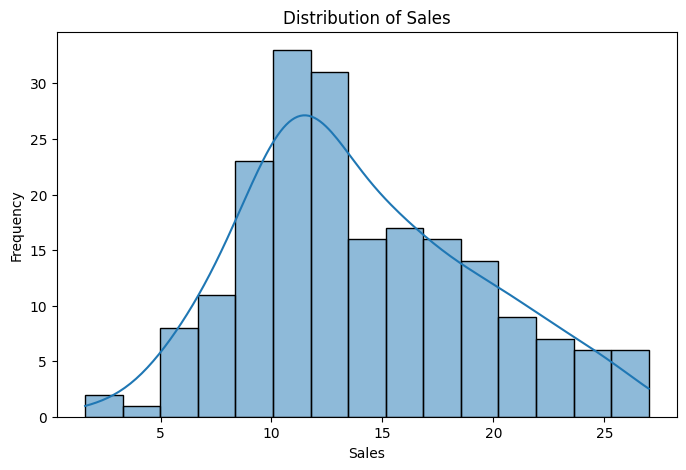

In [6]:
# Distribution of Sales

plt.figure(figsize=(8, 5))
sns.histplot(df["Sales"], bins=15, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

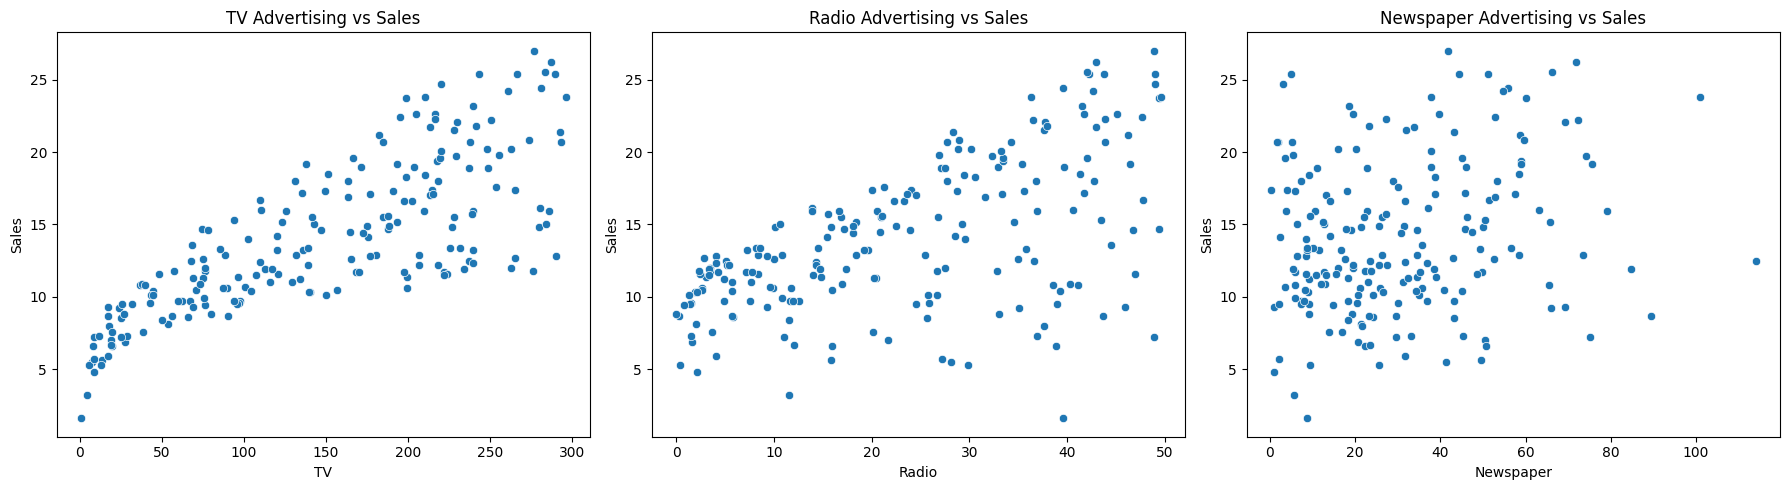

In [7]:
# Relationship between advertising channels and Sales

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="TV", y="Sales", ax=axes[0])
axes[0].set_title("TV Advertising vs Sales")

sns.scatterplot(data=df, x="Radio", y="Sales", ax=axes[1])
axes[1].set_title("Radio Advertising vs Sales")

sns.scatterplot(data=df, x="Newspaper", y="Sales", ax=axes[2])
axes[2].set_title("Newspaper Advertising vs Sales")

plt.tight_layout()
plt.show()

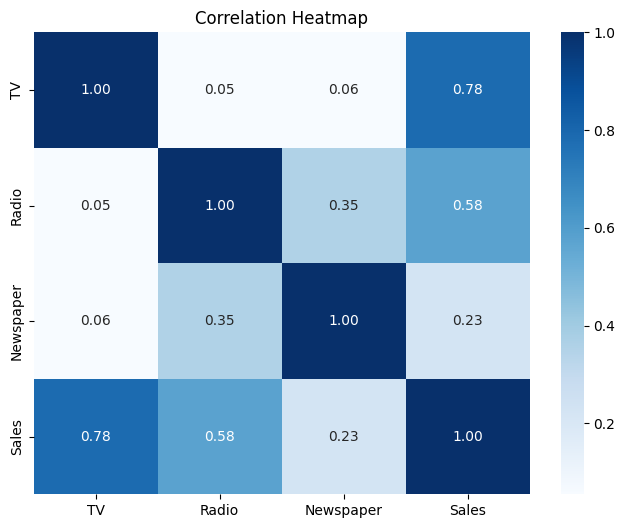

In [8]:
# Correlation between advertising channels and Sales

correlation = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="Blues", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()


In [9]:
# Separate input features and target variable

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [10]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


In [11]:
# Create and train the Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [12]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("First 10 Predicted Sales:")
print(y_pred[:10])

First 10 Predicted Sales:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [13]:
# Evaluate the model performance

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 2))

Model Performance
------------------
Mean Absolute Error (MAE): 1.46
Root Mean Squared Error (RMSE): 1.78
R² Score: 0.9


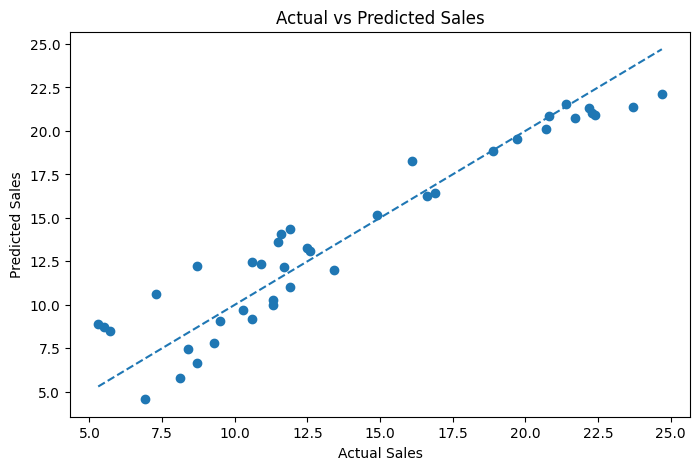

In [14]:
# Compare actual sales with predicted sales

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [15]:
# Analyze the impact of each advertising channel

coefficients = pd.DataFrame({
    "Advertising Channel": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients)

  Advertising Channel  Coefficient
1               Radio     0.189195
0                  TV     0.044730
2           Newspaper     0.002761


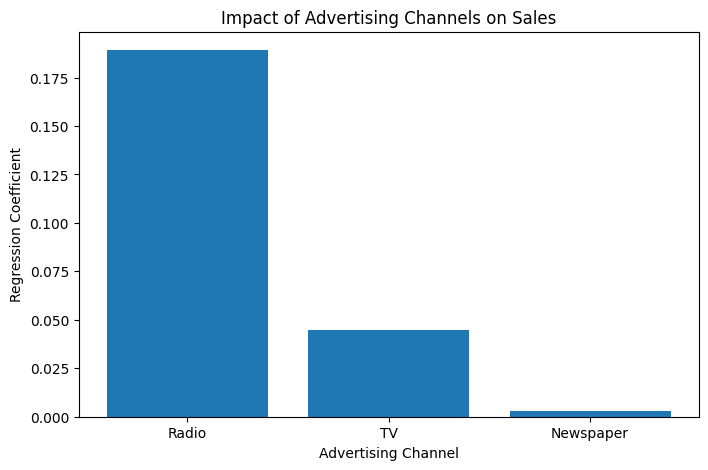

In [16]:
# Visualize the impact of advertising channels

plt.figure(figsize=(8, 5))

plt.bar(
    coefficients["Advertising Channel"],
    coefficients["Coefficient"]
)

plt.title("Impact of Advertising Channels on Sales")
plt.xlabel("Advertising Channel")
plt.ylabel("Regression Coefficient")

plt.show()

In [17]:
# Predict sales for a new advertising budget

new_advertising = pd.DataFrame({
    "TV": [150],
    "Radio": [30],
    "Newspaper": [20]
})

predicted_sales = model.predict(new_advertising)

print("Predicted Sales:", round(predicted_sales[0], 2))

Predicted Sales: 15.42


## Model Performance

The Linear Regression model achieved the following results on the test dataset:

| Metric | Result |
|---|---:|
| Mean Absolute Error (MAE) | 1.46 |
| Root Mean Squared Error (RMSE) | 1.78 |
| R² Score | 0.90 |

The R² score of 0.90 indicates that the model explains approximately 90%
of the variation in sales in the test dataset.

The MAE of 1.46 means that the model's predictions differ from the actual
sales values by about 1.46 units on average.

# Conclusion

In this project, a sales prediction model was developed using advertising
expenditure data from TV, Radio, and Newspaper channels.

The dataset was cleaned and explored using statistical analysis and
visualizations. A Linear Regression model was then trained using 80% of the
data and evaluated on the remaining 20%.

The model was evaluated using Mean Absolute Error (MAE), Root Mean Squared
Error (RMSE), and R² Score.

The analysis showed that Radio advertising had the strongest positive
relationship with predicted sales, followed by TV advertising. Newspaper
advertising had a comparatively smaller impact.

The trained model can also be used to estimate sales for a new advertising
budget. For example, an advertising budget of TV = 150, Radio = 30, and
Newspaper = 20 resulted in a predicted sales value of 15.42.

Overall, this project demonstrates how machine learning and data analysis
can be used to predict sales and support advertising-related business
decisions.